# <b>Training the MLP Model</b>

In this notebook, we're going to train the `MultiLayerPerceptron` that we've implemented with PyTorch and see how it performs before we do any tweaking on anything, neither the architecture, neural network layers, initialisation, the datasets or hyperparameters. Obviously we'll have a bad model as layers like CNNs perform better with images, but let's go through the process nonetheless. It's good for experience.

In [42]:
import os
print(f"Current Working Directory: {os.getcwd()}")

Current Working Directory: c:\Users\kmahl\Documents\ai-eng\personal-projects\learning-pytorch


In [43]:
wsl_path = "/root/Documents/ai-eng/learning-pytorch"
windows_path = "c:/Users/kmahl/Documents/ai-eng/personal-projects/learning-pytorch"

os.chdir(windows_path)
print(os.getcwd())

c:\Users\kmahl\Documents\ai-eng\personal-projects\learning-pytorch


In [ ]:
import torch
import torch.utils.data as data

from data.pytorchdata.catvnoncat import CatVsNonCatDataset

from models.MultiLayerPerceptron import MultiLayerPerceptron
from trainer.MLPTrainer import MLPTrainer
from trainer.utilities import get_latest_output_path
from models.model_visuals import plot_metric

import h5py
import numpy as np

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <b>Explore the dataset</b>

In [45]:
train_file_path = "data/rawdata/catvnoncat/train_catvnoncat.h5"
test_file_path = "data/rawdata/catvnoncat/test_catvnoncat.h5"

def explore_dataset(file_path, dataset_name, dataset_type):
  with h5py.File(file_path, "r") as file:
    print(f"Exploring {dataset_name} dataset:")
    
    print("Keys in the file:", list(file.keys()))
    
    images = file[f"{dataset_type}_set_x"][()]
    labels = file[f"{dataset_type}_set_y"][()]
    
    print(f"Number of images: {images.shape[0]}")
    print(f"Image shape: {images.shape[1:]}")
    print(f"Number of labels: {labels.shape[0]}")
    
    unique_labels, counts = np.unique(labels, return_counts=True)
    for label, count in zip(unique_labels, counts):
      print(f"Label {label}: {count} images")

In [46]:
explore_dataset(train_file_path, "Training", "train")

Exploring Training dataset:
Keys in the file: ['list_classes', 'train_set_x', 'train_set_y']
Number of images: 209
Image shape: (64, 64, 3)
Number of labels: 209
Label 0: 137 images
Label 1: 72 images


In [47]:
explore_dataset(test_file_path, "Test", "test")

Exploring Test dataset:
Keys in the file: ['list_classes', 'test_set_x', 'test_set_y']
Number of images: 50
Image shape: (64, 64, 3)
Number of labels: 50
Label 0: 17 images
Label 1: 33 images


In [48]:
train_dataset = CatVsNonCatDataset(train_file_path, train=True)
test_dataset = CatVsNonCatDataset(test_file_path, train=False)

The dataset consists of 209 training images and 50 test images, each with dimensions of 64x64 pixels and three color channels (RGB). The training set exhibits a notable class imbalance, with *Label 0* (137 samples) nearly doubling *Label 1* (72 samples); this **imbalance may bias the model toward the majority class if not addressed**.<br>

The test set, however, reverses this distribution, with *Label 1* (33 samples) outweighing *Label 0* (17 samples), suggesting **a potential mismatch between training and testing conditions that could impact generalization**.<br>

The consistent image dimensions eliminate the need for resizing, but the small dataset size (209 training samples) raises concerns about overfitting, **necessitating techniques like data augmentation**. Additionally, the discrepancy in class distributions between training and test sets warrants verification of label consistency and data sourcing to ensure representative splits. Further analysis should examine image quality, diversity (e.g., cat breeds, backgrounds), and potential biases to assess real-world applicability.

## Visual Inspection

In [49]:
def visualize_samples(dataset, n_samples=5):
  """Display n_samples of Label 0 (cats) and Label 1 (non-cats) in two rows."""

  np.random.seed(42)
  label_mask = dataset.labels.squeeze() == 0
  label_0_indices = np.where(label_mask)[0]
  label_1_indices = np.where(~label_mask)[0]
  
  selected_indices = [
    np.random.choice(label_0_indices, n_samples, replace=False),
    np.random.choice(label_1_indices, n_samples, replace=False)
  ]
  
  _, axes = plt.subplots(2, n_samples, figsize=(15, 6))
  
  for row, indices in enumerate(selected_indices):
    batch = torch.stack([dataset[i][0] for i in indices])
    imgs = batch.permute(0, 2, 3, 1).numpy()
    
    for col in range(n_samples):
      axes[row, col].imshow(imgs[col])
      axes[row, col].axis('off')
  
  axes[0, n_samples//2].set_title("Cats (Label 0)", fontsize=12)
  axes[1, n_samples//2].set_title("Non-Cats (Label 1)", fontsize=12)

  plt.suptitle("Random Training Samples")
  
  plt.tight_layout()
  plt.show()

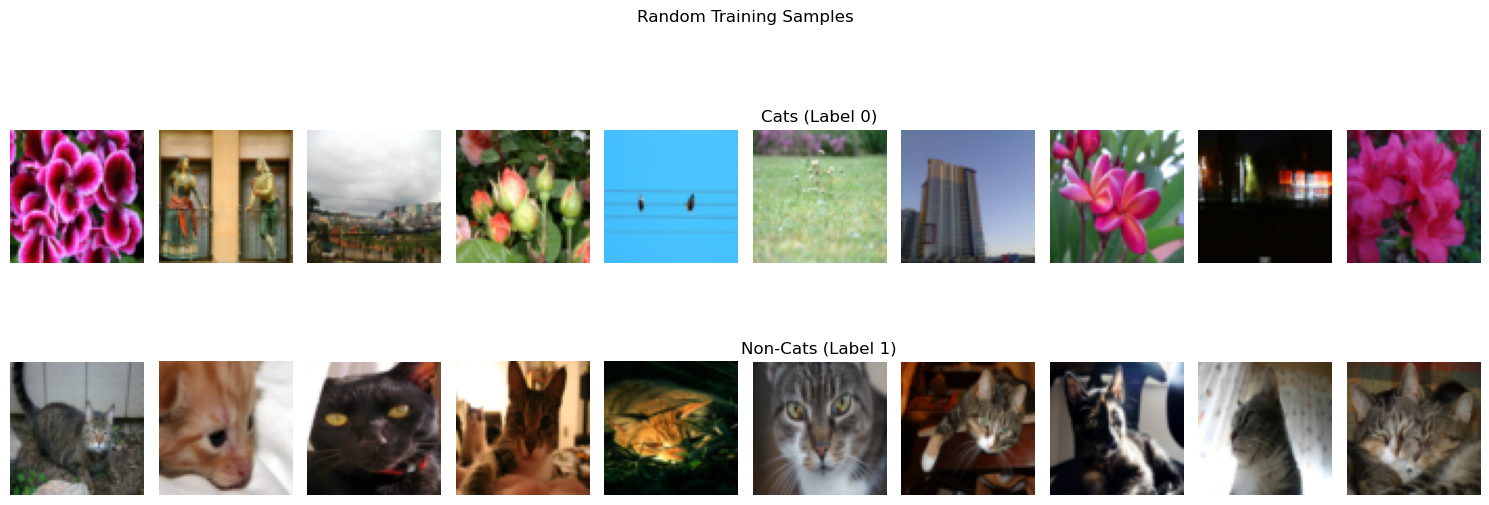

In [50]:
visualize_samples(train_dataset, n_samples=10)

## <b>Training the model</b>

In [51]:
input_size = 64 * 64 * 3  # 12288 pixels per image
output_size = 1  # Binary classification

# hyperparams
epochs = 150
batch_size = 16
learning_rate = 0.001
total_steps = 1500

model = MultiLayerPerceptron(
  layer_dims=[input_size, 512, 256, 128, 64, output_size], 
  activations=[torch.relu, torch.relu, torch.relu, torch.relu]
)

In [52]:
train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [53]:
trainer = MLPTrainer(model, train_loader, val_loader, loss_fn, optimizer, epochs=epochs)

In [54]:
trainer.train_steps(total_steps=total_steps)

In [55]:
latest_model_outputs = get_latest_output_path()

In [56]:
plot_metric(latest_model_outputs, "loss")

In [57]:
plot_metric(latest_model_outputs, "error")

next step is interpreting the results